In [1]:
import os
import polars as pl
import pandas as pd
import plotnine as pn

In [2]:
# Import the data
data = pl.read_csv("../Data/combined_data.csv", null_values="NA")

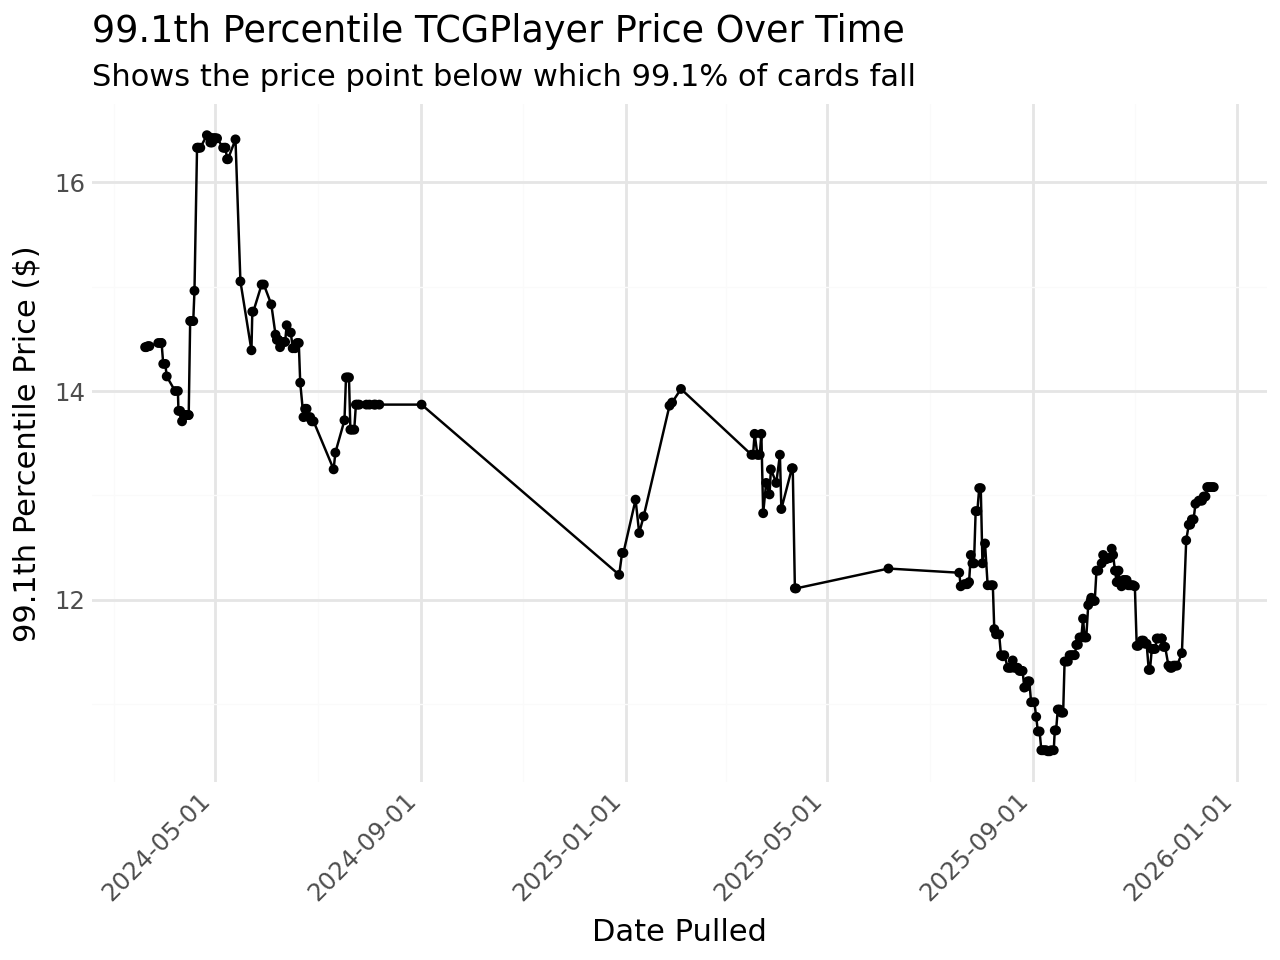

In [3]:
# Calculate summary statistics for each data pull (e.g., percentiles)
summary_stats = (
    data
    .group_by('time_pulled')
    .agg([
        pl.col('tcgplayer_price').quantile(0.991).alias('p99.1'),
        pl.col('tcgplayer_price').quantile(0.95).alias('p95'),
        pl.col('tcgplayer_price').quantile(0.5).alias('median'),
        pl.col('tcgplayer_price').mean().alias('mean'),
        pl.col('tcgplayer_price').count().alias('count')
    ])
    .rename({'time_pulled': 'date_pulled'})
    .sort('date_pulled')
)

# Convert summary_stats to pandas for plotting
summary_df = summary_stats.to_pandas()

# Convert date_pulled to datetime
summary_df['date_pulled'] = pd.to_datetime(summary_df['date_pulled'])

# Create the plot
(pn.ggplot(summary_df, pn.aes(x='date_pulled', y='p99.1')) +
 pn.geom_line() +
 pn.geom_point(size=1) +
 pn.theme_minimal() +
 pn.labs(title='99.1th Percentile TCGPlayer Price Over Time',
         x='Date Pulled',
         y='99.1th Percentile Price ($)',
         subtitle='Shows the price point below which 99.1% of cards fall') +
 pn.theme(axis_text_x=pn.element_text(rotation=45, hjust=1)))



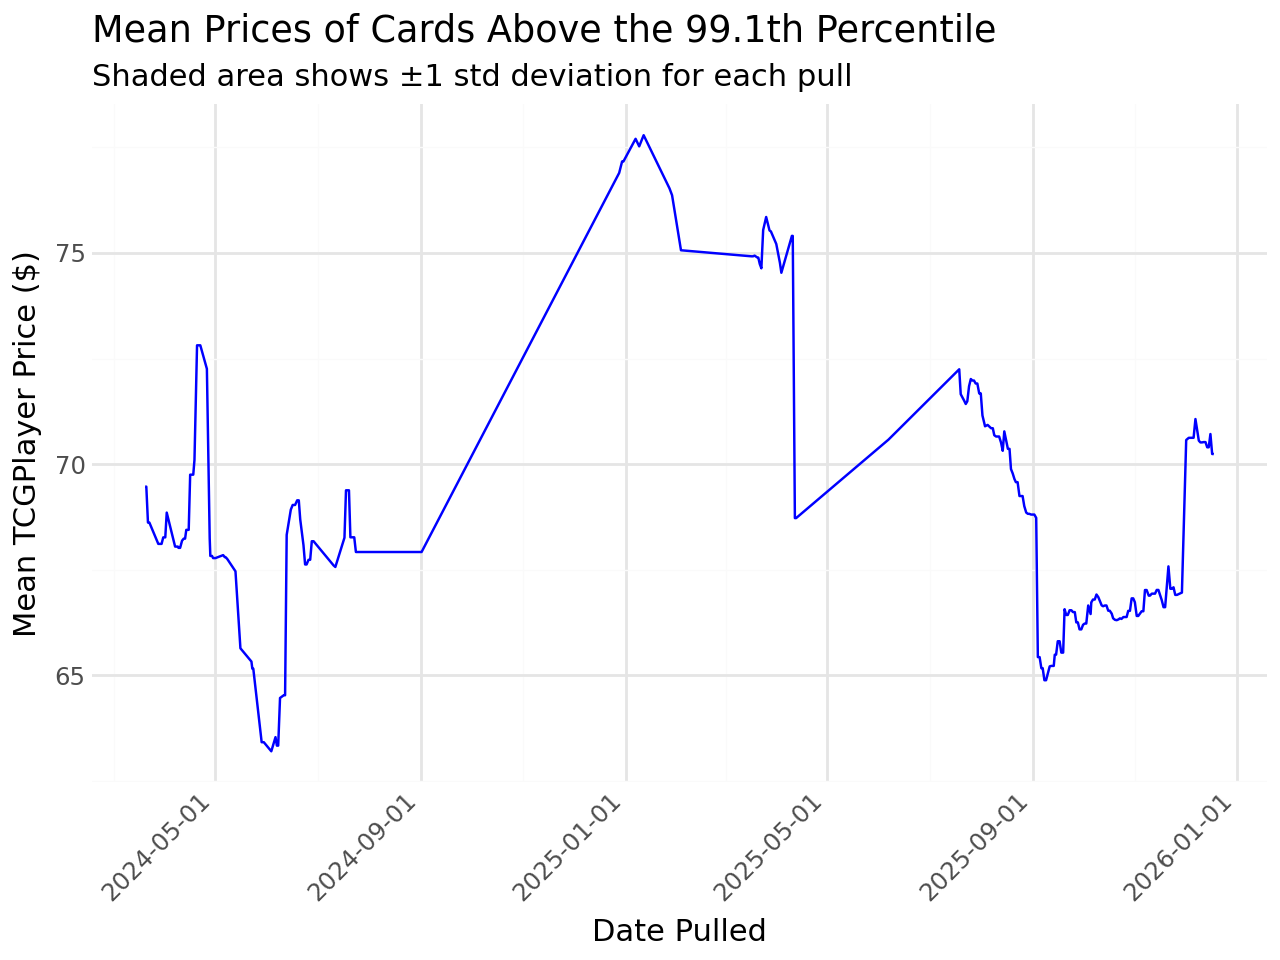

In [4]:
# Plot prices of cards above the 99.1th percentile for each time period

# Calculate the 99.1th percentile price for each time_pulled
p991_df = (
    data
    .group_by('time_pulled')
    .agg([
        pl.col('tcgplayer_price').quantile(0.991).alias('p991')
    ])
    .sort('time_pulled')
    .to_pandas()
)
p991_df['time_pulled'] = pd.to_datetime(p991_df['time_pulled'], errors='coerce')

# Merge the 99.1th percentile price back to the main data
card_prices = data.select(['id', 'name', 'time_pulled', 'tcgplayer_price']).to_pandas()
card_prices['time_pulled'] = pd.to_datetime(card_prices['time_pulled'], errors='coerce')
card_prices = card_prices.merge(p991_df, on='time_pulled', how='left')

# Filter for cards above the 99.1th percentile at each time point
above_p991 = card_prices[card_prices['tcgplayer_price'] > card_prices['p991']].copy()

above_p991.groupby('time_pulled').agg({'tcgplayer_price': ['mean', 'std', 'min', 'max']})

# Calculate mean and std for each time_pulled
agg_prices = above_p991.groupby('time_pulled').agg({
    'tcgplayer_price': ['mean', 'std']
}).reset_index()
agg_prices.columns = ['time_pulled', 'mean_price', 'std_price']
agg_prices['lower'] = agg_prices['mean_price'] - 0.5*agg_prices['std_price']
agg_prices['upper'] = agg_prices['mean_price'] + 0.5*agg_prices['std_price']

# Plot mean with std deviation shading
mean_plot = (
    pn.ggplot(agg_prices, pn.aes(x='time_pulled', y='mean_price')) +
    # pn.geom_ribbon(pn.aes(ymin='lower', ymax='upper'), fill='lightblue', alpha=0.3) +
    pn.geom_line(color='blue') +
    pn.theme_minimal() +
    pn.labs(
        title='Mean Prices of Cards Above the 99.1th Percentile',
        x='Date Pulled',
        y='Mean TCGPlayer Price ($)',
        subtitle='Shaded area shows ±1 std deviation for each pull'
    ) +
    pn.theme(axis_text_x=pn.element_text(rotation=45, hjust=1))
)

mean_plot

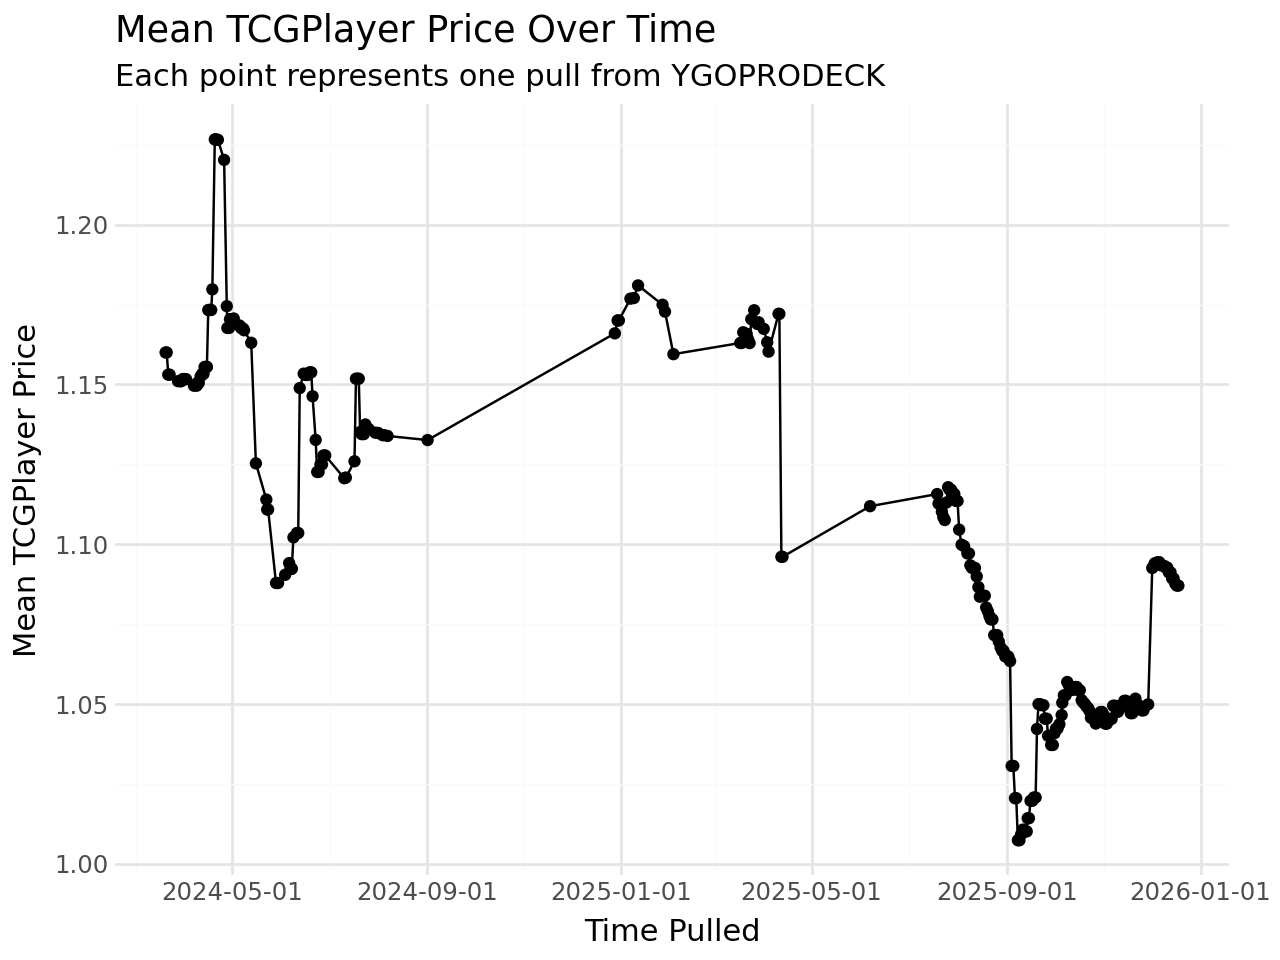

In [5]:
mean_price = data.group_by('time_pulled').agg(pl.col('tcgplayer_price').mean()).sort('time_pulled')

mean_price = mean_price.to_pandas()

mean_price['time_pulled'] = pd.to_datetime(mean_price['time_pulled'], errors='coerce')

pn.ggplot(mean_price, 
          pn.aes(x='time_pulled', 
                 y='tcgplayer_price')) + \
            pn.geom_line() + \
            pn.geom_point() + \
            pn.theme_minimal() + \
            pn.labs(title='Mean TCGPlayer Price Over Time',
                        x='Time Pulled', 
                        y='Mean TCGPlayer Price',
                        subtitle='Each point represents one pull from YGOPRODECK')

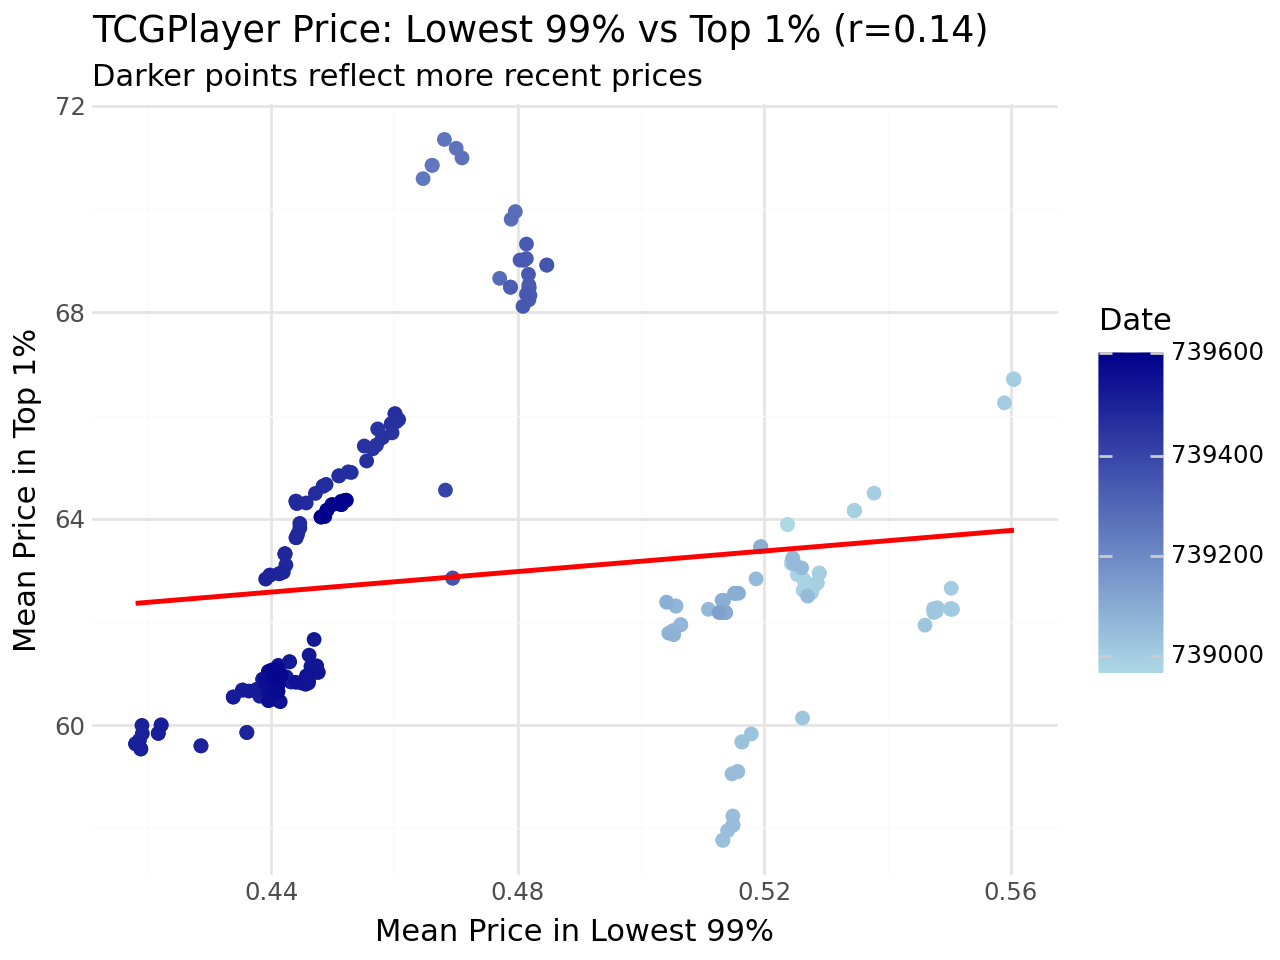

In [6]:
import numpy as np
from scipy.stats import pearsonr

# Get the lowest 99% and top 1% price cards for each time period
def get_percentile_prices(df):
    result = []
    for date, group in df.groupby('time_pulled'):
        prices = group['tcgplayer_price'].dropna()
        if len(prices) < 2:
            continue
        p99 = prices.quantile(0.99)
        # Lowest 99%: max price below 99th percentile
        low_99 = prices[prices <= p99].mean()
        # Top 1%: min price above 99th percentile
        top_1 = prices[prices > p99].mean()
        result.append({'date': date, 'low_99': low_99, 'top_1': top_1})
    return pd.DataFrame(result)

# Prepare the data
price_df = data.select(['time_pulled', 'tcgplayer_price']).to_pandas()
percentile_prices = get_percentile_prices(price_df)

# Convert 'date' to datetime for color mapping
percentile_prices['date'] = pd.to_datetime(percentile_prices['date'], errors='coerce')
percentile_prices['date_numeric'] = percentile_prices['date'].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

# Calculate correlation
corr, _ = pearsonr(percentile_prices['low_99'], percentile_prices['top_1'])

# Plot scatterplot with best-fit line and correlation, coloring points by date
scatter_plot = (
    pn.ggplot(percentile_prices, pn.aes(x='low_99', y='top_1', color='date_numeric')) +
    pn.geom_point(size=2) +
    pn.geom_smooth(method='lm', color='red', se=False) +
    pn.theme_minimal() +
    pn.labs(
        title=f'TCGPlayer Price: Lowest 99% vs Top 1% (r={corr:.2f})',
        subtitle = 'Darker points reflect more recent prices',
        x='Mean Price in Lowest 99%',
        y='Mean Price in Top 1%',
        color='Date'
    ) +
    pn.theme(legend_position='right') +
    pn.scale_color_gradient(low='lightblue', high='darkblue')
)

scatter_plot

# Economic Analysis
High Coefficient of Variation (CV): Cards in this price range have very inconsistent values at any given time

High Volatility: Cards in this price range experience dramatic price swings between data pulls

Both help identify where the "action" is in the market, avoiding bias from the mass of cheap cards that dominate simple averages.

### More info
*Coefficient of Variation (CV)*
Definition: CV = Standard Deviation / Mean

What it measures: Relative variability - how much variation exists relative to the average value.

Why it's useful for card prices:

A $1 standard deviation means very different things for a $2 card vs a $200 card
CV normalizes this: a CV of 0.5 means the standard deviation is 50% of the mean
Allows fair comparison across different price ranges
Example:

Cheap cards: Mean = $2, Std = $1 → CV = 0.5
Expensive cards: Mean = $100, Std = $20 → CV = 0.2
The cheap cards are actually MORE variable relative to their price


*Volatility*
Definition: Standard deviation of percentage price changes between time periods

What it measures: How much prices bounce around over time in percentage terms

Why percentage changes matter:
A $5 price change on a $10 card (50% change) is much more significant than on a $100 card (5% change)
Volatility captures this relative impact

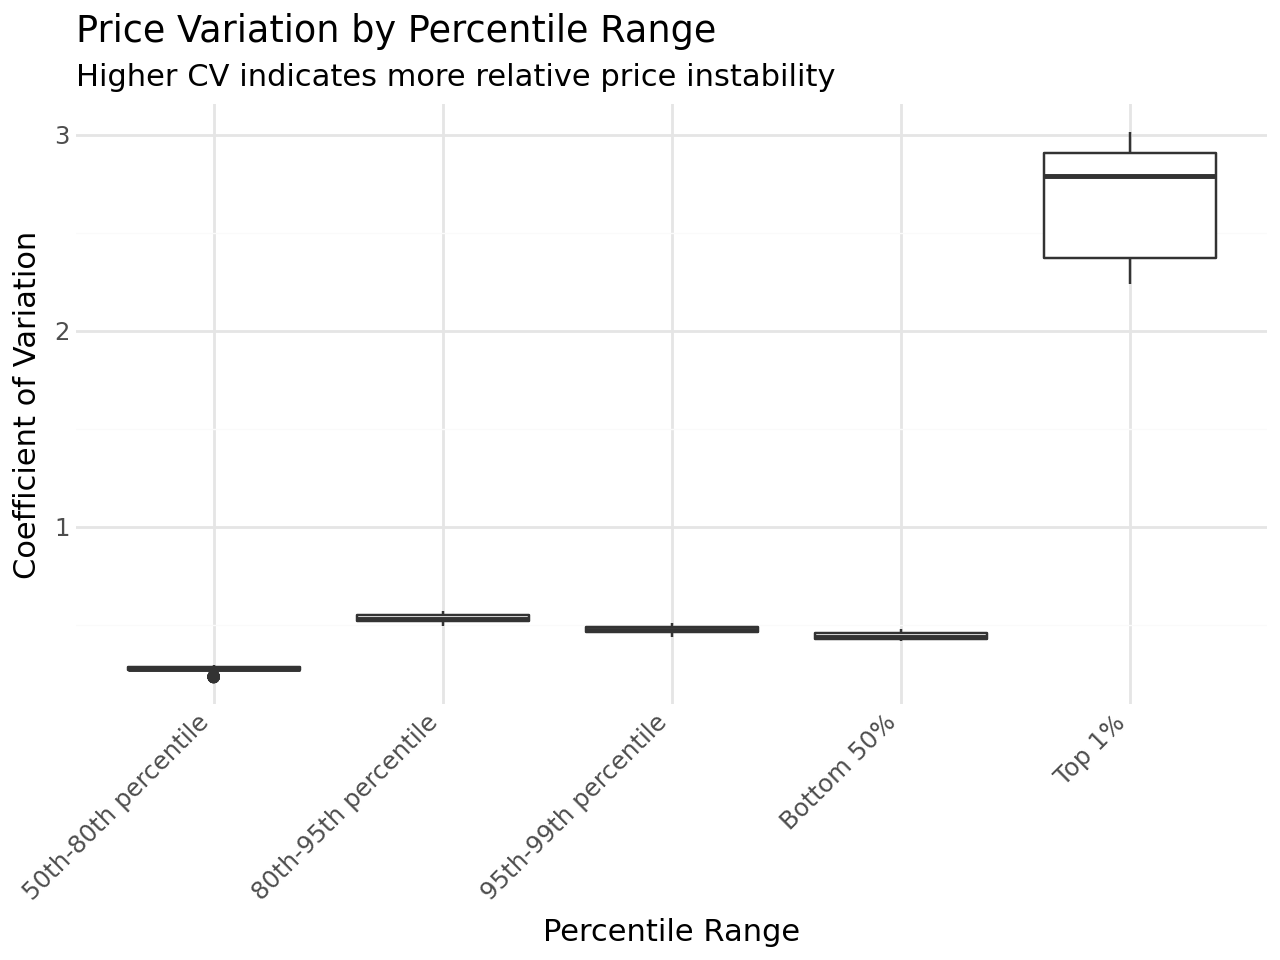

In [7]:
# Calculate coefficient of variation (CV) by percentile ranges
def analyze_variation_by_percentile():
    # Get all non-null price data
    price_data = data.filter(pl.col('tcgplayer_price').is_not_null())
    
    # Calculate percentile ranges for each time period
    percentile_analysis = []
    
    for time_period in price_data.select('time_pulled').unique().to_pandas()['time_pulled']:
        period_data = price_data.filter(pl.col('time_pulled') == time_period)
        prices = period_data.select('tcgplayer_price').to_pandas()['tcgplayer_price']
        
        # Define percentile ranges
        ranges = [
            (0, 50, "Bottom 50%"),
            (50, 80, "50th-80th percentile"), 
            (80, 95, "80th-95th percentile"),
            (95, 99, "95th-99th percentile"),
            (99, 100, "Top 1%")
        ]
        
        for lower, upper, label in ranges:
            lower_bound = prices.quantile(lower/100)
            upper_bound = prices.quantile(upper/100)
            
            subset = prices[(prices >= lower_bound) & (prices <= upper_bound)]
            if len(subset) > 1:
                cv = subset.std() / subset.mean()  # Coefficient of variation
                
                percentile_analysis.append({
                    'time_pulled': time_period,
                    'percentile_range': label,
                    'coefficient_of_variation': cv,
                    'mean_price': subset.mean(),
                    'std_price': subset.std(),
                    'count': len(subset)
                })
    
    return pd.DataFrame(percentile_analysis)

cv_analysis = analyze_variation_by_percentile()

# Plot coefficient of variation by percentile range
(pn.ggplot(cv_analysis, pn.aes(x='percentile_range', y='coefficient_of_variation')) +
 pn.geom_boxplot() +
 pn.theme_minimal() +
 pn.theme(axis_text_x=pn.element_text(rotation=45, hjust=1)) +
 pn.labs(title='Price Variation by Percentile Range',
         x='Percentile Range',
         y='Coefficient of Variation',
         subtitle='Higher CV indicates more relative price instability'))

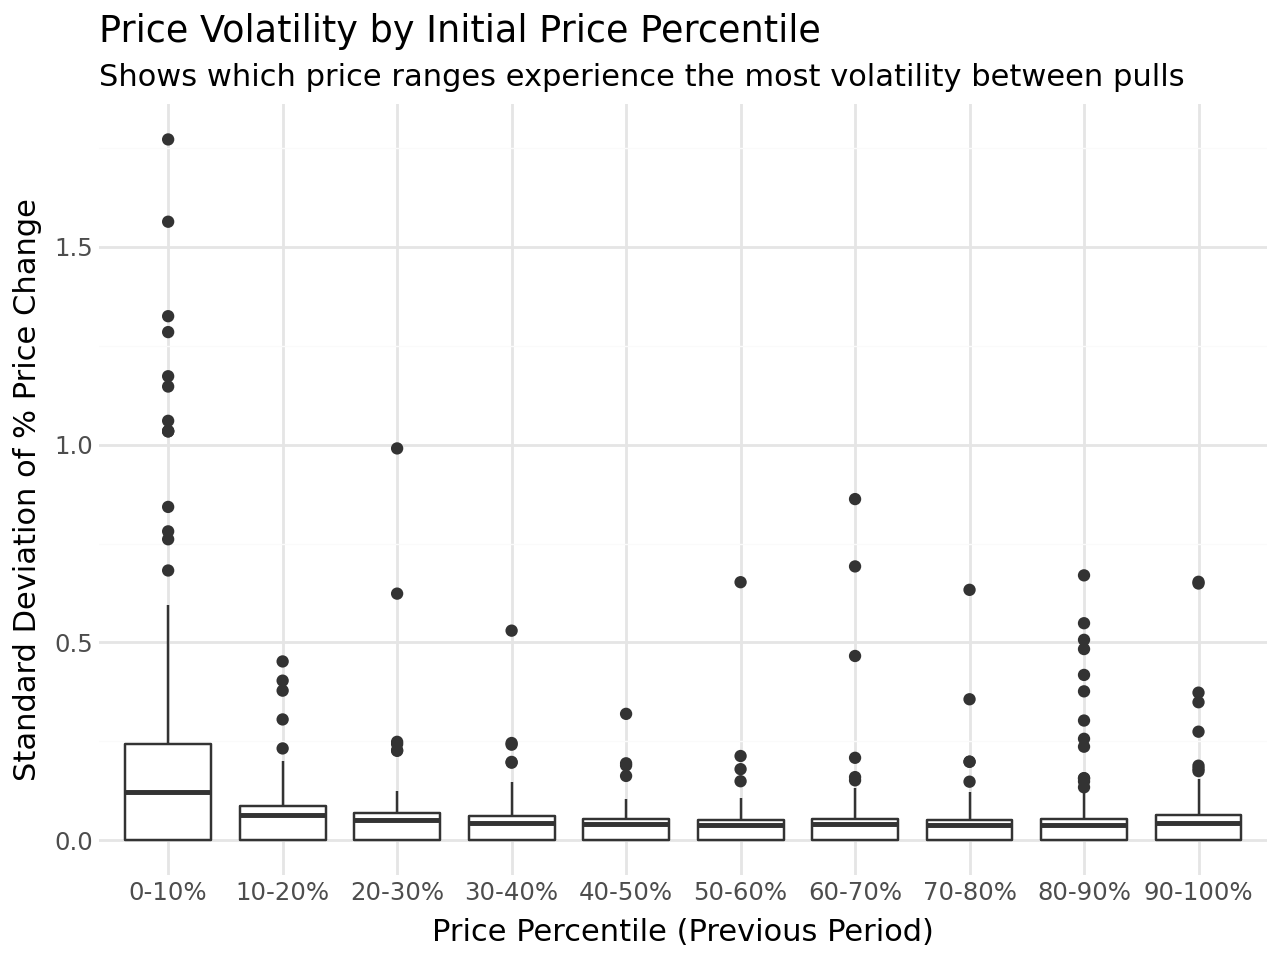

In [8]:
# Alternative: Track price changes over time for different percentile groups
def track_percentile_volatility():
    # Calculate rolling volatility for different percentile groups
    volatility_data = []
    
    times = data.select('time_pulled').unique().sort('time_pulled').to_pandas()['time_pulled'].tolist()
    
    for i in range(1, len(times)):
        prev_time = times[i-1]
        curr_time = times[i]
        
        # Get cards that exist in both time periods
        prev_data = data.filter(pl.col('time_pulled') == prev_time).select(['id', 'tcgplayer_price'])
        curr_data = data.filter(pl.col('time_pulled') == curr_time).select(['id', 'tcgplayer_price'])
        
        # Join to get price changes
        price_changes = prev_data.join(curr_data, on='id', suffix='_curr').with_columns([
            ((pl.col('tcgplayer_price_curr') - pl.col('tcgplayer_price')) / pl.col('tcgplayer_price')).alias('pct_change')
        ]).filter(
            (pl.col('tcgplayer_price').is_not_null()) & 
            (pl.col('tcgplayer_price_curr').is_not_null()) &
            (pl.col('tcgplayer_price') > 0)
        )
        
        if price_changes.height > 0:
            changes_df = price_changes.to_pandas()
            
            # Assign percentile groups based on previous period price
            changes_df['price_percentile'] = pd.qcut(changes_df['tcgplayer_price'], 
                                                   q=10, 
                                                   labels=['0-10%',
                                                           '10-20%',
                                                           '20-30%',
                                                           '30-40%',
                                                           '40-50%',
                                                           '50-60%', 
                                                           '60-70%', 
                                                           '70-80%', 
                                                           '80-90%', 
                                                           '90-100%'])
            
            # Calculate volatility metrics by percentile group
            volatility_by_group = changes_df.groupby('price_percentile',
                                                     observed=False).agg({
                'pct_change': ['std', 'mean', 'count']
            }).round(4)
            
            volatility_by_group.columns = ['volatility', 'mean_change', 'count']
            volatility_by_group['time_transition'] = f"{prev_time} → {curr_time}"
            volatility_by_group = volatility_by_group.reset_index()
            
            volatility_data.append(volatility_by_group)
    
    return pd.concat(volatility_data, ignore_index=True)

volatility_df = track_percentile_volatility()

# Plot volatility by price percentile
(pn.ggplot(volatility_df, pn.aes(x='price_percentile', y='volatility')) +
 pn.geom_boxplot() +
 pn.theme_minimal() +
 pn.labs(title='Price Volatility by Initial Price Percentile',
         x='Price Percentile (Previous Period)',
         y='Standard Deviation of % Price Change',
         subtitle='Shows which price ranges experience the most volatility between pulls'))

## Why This Is Better thank Just Percentile Rank:
Forward-looking: Recent volatility suggests continued price instability

Price-relevant: Focuses on cards with meaningful price levels

Responsive: Will quickly identify newly volatile cards

Actionable: High volatility = trading/investment opportunities

# Cards to Watch

In [9]:
# Fix card names by using the most recent name for each ID
def standardize_card_names(data):
    """
    For each card ID, use the most recent non-null name across all time periods
    """
    # Get the most recent non-null name for each card ID
    most_recent_names = (
        data
        .filter(pl.col('name').is_not_null())  # Only consider non-null names
        .sort('time_pulled', descending=True)  # Sort by most recent first
        .group_by('id')
        .first()  # Take the first (most recent) name for each ID
        .select(['id', 'name'])
        .rename({'name': 'corrected_name'})
    )
    
    # Join back to original data and replace names
    corrected_data = (
        data
        .join(most_recent_names, on='id', how='left')
        .with_columns([
            # Use corrected_name if available, otherwise keep original name
            pl.when(pl.col('corrected_name').is_not_null())
            .then(pl.col('corrected_name'))
            .otherwise(pl.col('name'))
            .alias('name')
        ])
        .drop('corrected_name')
    )
    
    return corrected_data

# Apply the correction
print("Before correction - cards with null names:")
null_names_before = data.filter(pl.col('name').is_null()).height
print(f"Count: {null_names_before}")

# Standardize the names
data_corrected = standardize_card_names(data)

print("\nAfter correction - cards with null names:")
null_names_after = data_corrected.filter(pl.col('name').is_null()).height
print(f"Count: {null_names_after}")

# Check a specific example to verify the correction worked
print("\nExample: Check how names changed for a specific ID")
example_id = data.filter(pl.col('name') == 'Artmage Finmel').select('id').limit(1).to_pandas()
if not example_id.empty:
    test_id = example_id['id'].iloc[0]
    
    print(f"\nBefore correction for ID {test_id}:")
    before_example = data.filter(pl.col('id') == test_id).select(['time_pulled', 'name']).sort('time_pulled')
    print(before_example.to_pandas())
    
    print(f"\nAfter correction for ID {test_id}:")
    after_example = data_corrected.filter(pl.col('id') == test_id).select(['time_pulled', 'name']).sort('time_pulled')
    print(after_example.to_pandas())

# Update the global data variable
data = data_corrected

Before correction - cards with null names:
Count: 749

After correction - cards with null names:
Count: 0

Example: Check how names changed for a specific ID

Before correction for ID 34541940:
              time_pulled               name
0    2025-06-06T21:07:06Z  Artmegia Finemelt
1    2025-07-19T02:38:19Z     Artmage Finmel
2    2025-07-20T00:01:33Z     Artmage Finmel
3    2025-07-22T02:17:31Z     Artmage Finmel
4    2025-07-23T00:06:10Z     Artmage Finmel
..                    ...                ...
135  2025-12-14T02:45:17Z     Artmage Finmel
136  2025-12-15T00:33:23Z     Artmage Finmel
137  2025-12-16T00:38:54Z     Artmage Finmel
138  2025-12-17T01:36:59Z     Artmage Finmel
139  2025-12-18T00:39:09Z     Artmage Finmel

[140 rows x 2 columns]

After correction for ID 34541940:
              time_pulled            name
0    2025-06-06T21:07:06Z  Artmage Finmel
1    2025-07-19T02:38:19Z  Artmage Finmel
2    2025-07-20T00:01:33Z  Artmage Finmel
3    2025-07-22T02:17:31Z  Artmage Finm

In [10]:
def identify_cards_to_watch():
    """Identify cards with recent high volatility and significant price movements"""
    
    # Get the last 3-4 time periods for recent analysis
    recent_times = data.select('time_pulled').unique().sort('time_pulled', descending=True).head(4)
    recent_time_list = recent_times.to_pandas()['time_pulled'].tolist()
    
    # Get price data for recent periods
    recent_data = data.filter(
        (pl.col('time_pulled').is_in(recent_time_list)) & 
        (pl.col('tcgplayer_price').is_not_null()) &
        (pl.col('tcgplayer_price') > 0.5)  # Filter out very cheap cards
    ).select(['id', 'name', 'time_pulled', 'tcgplayer_price'])
    
    cards_to_watch = []
    
    # Group by card and calculate recent metrics
    for card_id in recent_data.select('id').unique().to_pandas()['id']:
        card_data = recent_data.filter(pl.col('id') == card_id).sort('time_pulled')
        
        if card_data.height >= 3:  # Need at least 3 data points
            prices = card_data.select('tcgplayer_price').to_pandas()['tcgplayer_price']
            name = card_data.select('name').to_pandas()['name'].iloc[0]
            
            # Calculate percentage changes
            pct_changes = prices.pct_change().dropna()
            
            if len(pct_changes) >= 2:
                # Recent volatility (std of % changes)
                recent_volatility = pct_changes.std()
                
                # Price momentum (latest vs first price)
                price_momentum = (prices.iloc[-1] - prices.iloc[0]) / prices.iloc[0]
                
                # Current price level
                current_price = prices.iloc[-1]
                
                # Size of recent moves
                max_recent_move = pct_changes.abs().max()
                
                cards_to_watch.append({
                    'id': card_id,
                    'name': name,
                    'current_price': current_price,
                    'recent_volatility': recent_volatility,
                    'price_momentum': price_momentum,
                    'max_recent_move': max_recent_move,
                    'data_points': len(prices)
                })
    
    watch_df = pd.DataFrame(cards_to_watch)
    
    # Create composite "watch score" 
    # High volatility + significant recent movement + reasonable price level
    watch_df['watch_score'] = (
        watch_df['recent_volatility'] * 2 +  # Weight volatility heavily
        watch_df['max_recent_move'] * 1.5 +  # Recent big moves
        (watch_df['current_price'].apply(lambda x: min(x/10, 1)))  # Price relevance (cap benefit at $10)
    )
    
    return watch_df.sort_values('watch_score', ascending=False)

# Run the analysis
watch_list = identify_cards_to_watch()

# Display top cards to watch
print("TOP 15 CARDS TO WATCH:")
print(watch_list.head(15)[['name', 'current_price', 'recent_volatility', 'price_momentum', 'watch_score']].round(3))

TOP 15 CARDS TO WATCH:
                                            name  current_price  \
1607                              Hundred Dragon           2.91   
1755                          Lunalight Gold Leo          12.18   
589                           Secreterion Dragon          17.25   
1467                   Arms of Genex Return Zero           2.91   
80                        Vanquish Soul Jiaolong          14.12   
509                              Dominus Impulse          34.37   
1772  Winged Dragon, Guardian of the Fortress #2          25.16   
409                           Gem-Knight Nepyrim          13.60   
180                        Tenyi Spirit - Suruya           9.17   
413                       Sky Striker Ace = Zero          27.27   
494                         Despian Luluwalilith          14.51   
841                   Primite Dragon Ether Beryl          12.69   
2124               Shooting Majestic Star Dragon          32.06   
523                         Ultimate Ax

In [11]:
# Daily alert version - run this each day
def daily_watch_alerts(volatility_threshold=0.15, momentum_threshold=0.20):
    """Generate daily alerts for cards showing concerning activity"""
    
    watch_df = identify_cards_to_watch()
    
    # High volatility alerts
    high_vol = watch_df[watch_df['recent_volatility'] > volatility_threshold]
    
    # Strong momentum alerts  
    strong_momentum = watch_df[abs(watch_df['price_momentum']) > momentum_threshold]
    
    print(f"🔥 HIGH VOLATILITY ALERTS ({len(high_vol)} cards):")
    for _, card in high_vol.head(10).iterrows():
        print(f"  • {card['name']}: ${card['current_price']:.2f} (volatility: {card['recent_volatility']:.1%})")
    
    print(f"\n📈 STRONG MOMENTUM ALERTS ({len(strong_momentum)} cards):")
    for _, card in strong_momentum.head(10).iterrows():
        direction = "📈" if card['price_momentum'] > 0 else "📉"
        print(f"  • {direction} {card['name']}: {card['price_momentum']:.1%} momentum")

daily_watch_alerts()

🔥 HIGH VOLATILITY ALERTS (6 cards):
  • Hundred Dragon: $2.91 (volatility: 29.7%)
  • Arms of Genex Return Zero: $2.91 (volatility: 24.2%)
  • Deftero Enneacraft - "alazoneIA": $0.51 (volatility: 18.9%)
  • Enneacraft - Asta.PIXEA: $0.51 (volatility: 18.1%)
  • Enneacraft - Aiza.LEON: $0.61 (volatility: 17.8%)
  • Enneacraft - Archa.TAIL: $0.67 (volatility: 15.8%)

📈 STRONG MOMENTUM ALERTS (26 cards):
  • 📈 Hundred Dragon: 50.0% momentum
  • 📈 Lunalight Gold Leo: 23.2% momentum
  • 📉 Arms of Genex Return Zero: -33.6% momentum
  • 📉 Deftero Enneacraft - "alazoneIA": -48.0% momentum
  • 📉 Enneacraft - Asta.PIXEA: -42.0% momentum
  • 📉 Enneacraft - Aiza.LEON: -42.5% momentum
  • 📉 Enneacraft - Archa.TAIL: -37.4% momentum
  • 📉 Ekto Enneacraft - "tromarIA": -39.8% momentum
  • 📉 Enneapolis: -35.6% momentum
  • 📈 Disaster, Dragon Ruler of All Apocalypses: 30.6% momentum


In [12]:
# Get the most recent time for filtering
most_recent_time = data.select('time_pulled').unique().sort('time_pulled', descending=True).head(1).to_pandas()['time_pulled'].iloc[0]

# Helper function to wrap text at specified character limit
def wrap_text(text, char_limit=20):
    """Wrap text to multiple lines based on character limit"""
    # Handle None/null values
    if text is None or pd.isna(text):
        return "Unknown Card"
    
    text = str(text)  # Ensure it's a string
    
    if len(text) <= char_limit:
        return text
    
    words = text.split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= char_limit:
            if current_line:
                current_line += " " + word
            else:
                current_line = word
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

# Get high volatility and strong momentum cards from the daily alerts
high_vol_cards = watch_list[watch_list['recent_volatility'] > 0.15].head(20)
strong_momentum_cards = watch_list[abs(watch_list['price_momentum']) > 0.20].head(20)

# Get historical price data for high volatility cards
high_vol_price_data = data.filter(
    (pl.col('id').is_in(high_vol_cards['id'].tolist())) &
    (pl.col('tcgplayer_price').is_not_null())
).select(['id', 'name', 'time_pulled', 'tcgplayer_price']).to_pandas()

high_vol_price_data['time_pulled'] = pd.to_datetime(high_vol_price_data['time_pulled'], errors='coerce')

# Add volatility data for color coding and wrap card names
volatility_lookup = high_vol_cards.set_index('id')['recent_volatility'].to_dict()
high_vol_price_data['volatility'] = high_vol_price_data['id'].map(volatility_lookup)
high_vol_price_data['name_wrapped'] = high_vol_price_data['name'].apply(wrap_text)

# Filter out any rows where mapping failed (momentum is NaN) or name is None/NaN
high_vol_price_data = high_vol_price_data.dropna(subset=['name', 'volatility'])

# Create high volatility plot with blue gradient based on volatility
high_vol_plot = (pn.ggplot(high_vol_price_data, 
                           pn.aes(x='time_pulled', y='tcgplayer_price', color='volatility')) +
                 pn.geom_line() +
                 pn.geom_point(size=0.5) +
                 pn.scale_color_gradient(low='lightblue', high='darkblue', name='Volatility') +
                 pn.facet_wrap('~name_wrapped', scales='free_y', ncol=4) +
                 pn.theme_minimal() +
                 pn.theme(legend_position='bottom',
                          axis_text_x=pn.element_text(rotation=45, size = 4, hjust=1),
                          strip_text=pn.element_text(size=8)) +
                 pn.labs(title='Historical TCGPlayer Prices for High Volatility Cards',
                         x='Time Pulled',
                         y='TCGPlayer Price'))



# Get historical price data for strong momentum cards
strong_momentum_price_data = data.filter(
    (pl.col('id').is_in(strong_momentum_cards['id'].tolist())) &
    (pl.col('tcgplayer_price').is_not_null())
).select(['id', 'name', 'time_pulled', 'tcgplayer_price']).to_pandas()

strong_momentum_price_data['time_pulled'] = pd.to_datetime(strong_momentum_price_data['time_pulled'], errors='coerce')

# Add momentum data and color coding and wrap card names
momentum_lookup = strong_momentum_cards.set_index('id')['price_momentum'].to_dict()
strong_momentum_price_data['momentum'] = strong_momentum_price_data['id'].map(momentum_lookup)

# Filter out any rows where mapping failed (momentum is NaN) or name is None/NaN
strong_momentum_price_data = strong_momentum_price_data.dropna(subset=['name', 'momentum'])

# Wrap card names for better display
strong_momentum_price_data['name_wrapped'] = strong_momentum_price_data['name'].apply(wrap_text)

# Create strong momentum plot with gradient color based on momentum value
strong_momentum_plot = (
    pn.ggplot(strong_momentum_price_data, 
              pn.aes(x='time_pulled', y='tcgplayer_price', color='momentum')) +
    pn.geom_line() +
    pn.geom_point(size=0.5) +
    pn.scale_color_gradient2(low='deepskyblue', mid='white', high='darkorange', midpoint=0, name='Momentum') +
    pn.facet_wrap('~name_wrapped', scales='free_y', ncol=4) +
    pn.theme_minimal() +
    pn.theme(legend_position='bottom',
             axis_text_x=pn.element_text(rotation=45, size=4, hjust=1),
             strip_text=pn.element_text(size=8)) +
    pn.labs(title='Historical TCGPlayer Prices for Strong Momentum Cards',
            x='Time Pulled',
            y='TCGPlayer Price')
)

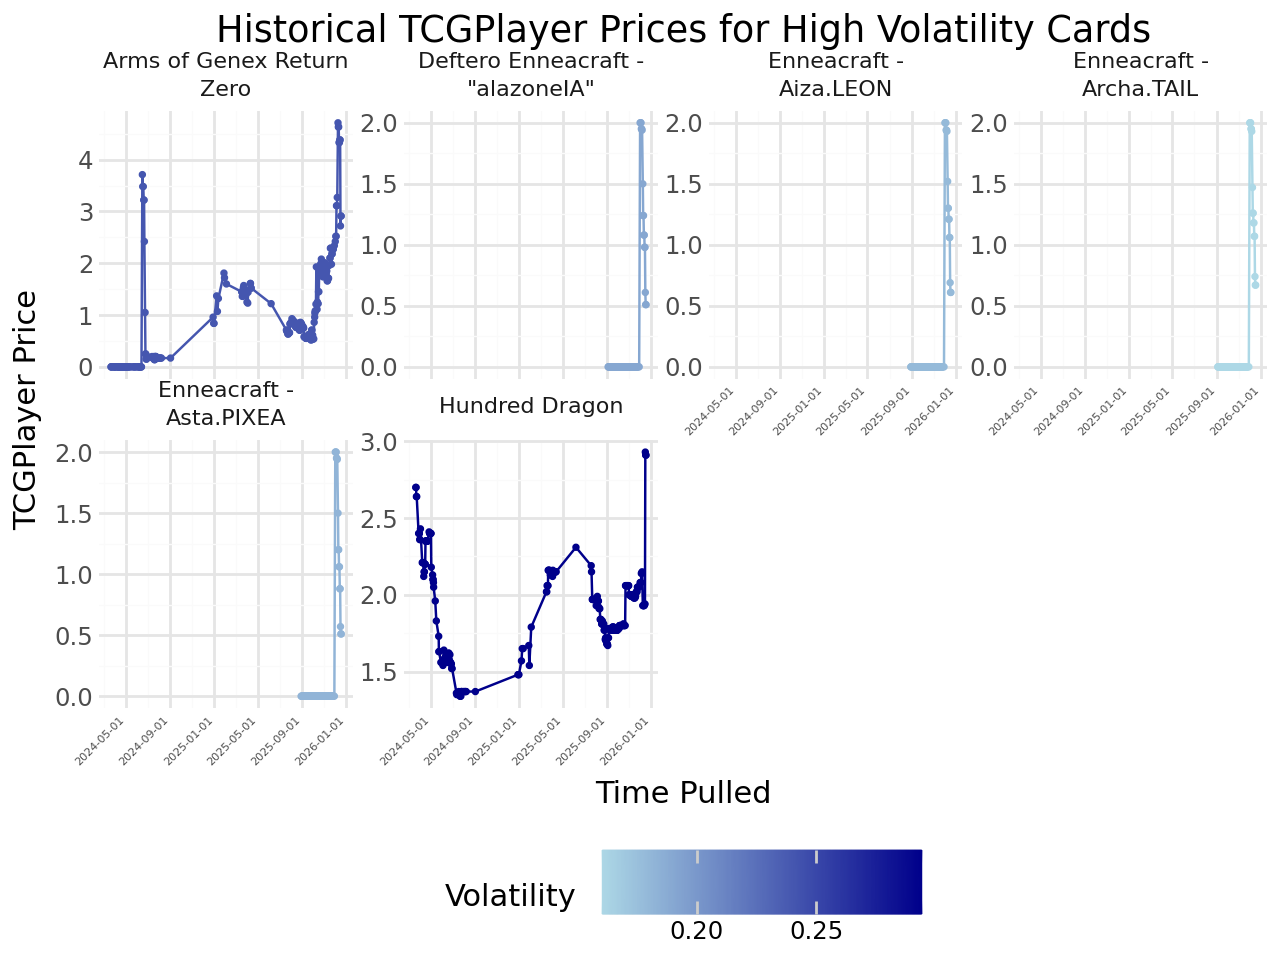

In [13]:
high_vol_plot

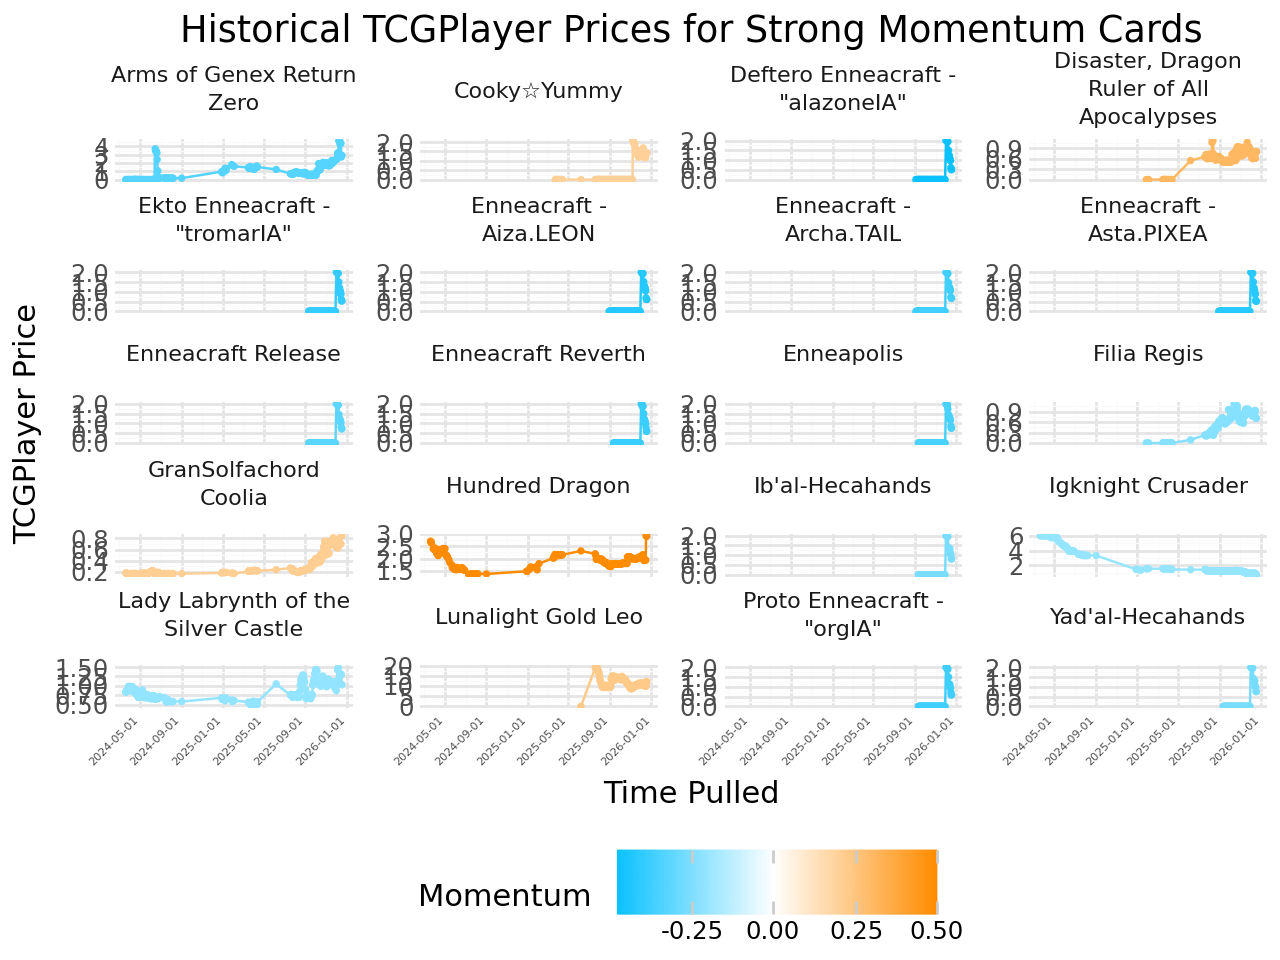

In [14]:
strong_momentum_plot

# Key Metrics Explained

### Coefficient of Variation (CV)
**Definition**: CV = Standard Deviation / Mean

**What it measures**: Relative variability - how much prices vary compared to their average value.

**Example**: 
- Card A: Mean $2, Std $1 → CV = 0.5 (50% variation)
- Card B: Mean $100, Std $20 → CV = 0.2 (20% variation)

Card A is actually MORE variable relative to its price level.

### Volatility
**Definition**: Standard deviation of percentage price changes between time periods.

**What it measures**: How much prices bounce around over time in percentage terms.

**Why percentage matters**: A $5 change on a $10 card (50%) is much more significant than on a $100 card (5%).

### Momentum
**Definition**: Overall price direction over recent periods (latest price vs. earlier price / earlier price).

**What it measures**: Whether prices are trending up or down and by how much.

## Should These Be Included in Price Prediction Models?

**Yes, but with important considerations:**

### **Strong Predictive Value**
- **CV**: Identifies cards with inherently unstable pricing → expect continued instability
- **Volatility**: Recent price swings often predict future swings → market inefficiency signals
- **Momentum**: Price trends tend to persist in the short term → behavioral finance effects

### **Model Implementation**
- Use as **features**, not targets
- **Rolling calculations** (last 3-7 periods) for recent behavior
- **Interaction terms** with other features (rarity, set age, competitive play)
- **Regime detection** - different models for high/low volatility periods

### **Cautions**
- **Look-ahead bias**: Only use historical volatility/momentum available at prediction time
- **Non-stationarity**: Market conditions change; recent volatility may not persist
- **Overfitting**: These metrics can be noisy; use regularization

### **Best Practice**
Combine all three in a **composite "market activity" score** that identifies cards worth monitoring, then build separate models for different activity levels.